# 🚀 Notebook 07: Improved GAT Training
## Explainable GNNs for ASD Classification — Enhanced Architecture

**Goal:** Push test accuracy from **52.7% → 65%+** and sensitivity from **26% → 60%+**

### Key Improvements Over Notebook 04 Baseline
| Component | Baseline (NB04) | Improved (NB07) |
|---|---|---|
| GAT layers | 2 | **3** |
| Batch Normalization | ❌ | ✅ |
| Graph pooling | Mean only | **Mean + Max** |
| Loss function | CrossEntropy | **Weighted CrossEntropy** |
| LR Scheduler | None | **ReduceLROnPlateau** |
| Gradient clipping | None | **max_norm=1.0** |
| Training epochs | 120 | **300** |
| Checkpoint criterion | Val Accuracy | **Val F1** (better for imbalanced) |
| Cross-Validation | None | **5-Fold Stratified CV** |

> ⚡ **Runtime:** Use GPU for ~10 min total. CPU will take ~40–60 min.

In [1]:
# ─── CELL 1: Install All Dependencies ────────────────────────────────────────
import subprocess, sys

print("📦 Installing torch_geometric...")
subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch_geometric', '-q'], check=True)

import torch
cuda_tag = 'cu' + torch.version.cuda.replace('.','') if torch.cuda.is_available() else 'cpu'
pyg_url  = f'https://data.pyg.org/whl/torch-{torch.__version__.split("+")[0]}+{cuda_tag}.html'
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch_scatter', 'torch_sparse', 'torch_cluster', 'torch_spline_conv',
    '-f', pyg_url
], check=False)

print(f"\n✅ Setup complete! PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

📦 Installing torch_geometric...

✅ Setup complete! PyTorch 2.11.0+cpu | CUDA: False


In [2]:
# ─── CELL 2: All Imports ──────────────────────────────────────────────────────
import os
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch.nn.functional as F
from torch.nn import Linear, BatchNorm1d
from torch_geometric.loader import DataLoader
from torch_geometric.data import Dataset
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)
from google.colab import drive

plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.titlesize': 13,
                     'axes.labelsize': 11})
print("✅ All imports successful")

✅ All imports successful


In [3]:
# ─── CELL 3: Mount Drive & Paths ──────────────────────────────────────────────
drive.mount('/content/drive')

BASE_DIR       = '/content/drive/MyDrive/ASD_GNN_Research2'
GRAPHS_DIR     = os.path.join(BASE_DIR, 'graphs')
CKPT_DIR       = os.path.join(BASE_DIR, 'models', 'Checkpoints')
IMPROVED_DIR   = os.path.join(BASE_DIR, 'models', 'GAT')
METRICS_DIR    = os.path.join(BASE_DIR, 'results', 'metrics')
FIGURES_DIR    = os.path.join(BASE_DIR, 'results', 'figures')

os.makedirs(IMPROVED_DIR, exist_ok=True)
os.makedirs(METRICS_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR,  exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Drive mounted | Device: {DEVICE}")
print(f"   Improved model will be saved to: {IMPROVED_DIR}")

Mounted at /content/drive
✅ Drive mounted | Device: cpu
   Improved model will be saved to: /content/drive/MyDrive/ASD_GNN_Research2/models/GAT


---
## 🏗️ Section 1: Improved Model Architecture

In [4]:
# ─── CELL 4: Dataset + Improved Model Architecture ───────────────────────────
class ABIDEGraphDataset(Dataset):
    def __init__(self, folder_path):
        super().__init__()
        self.folder_path = folder_path
        self.file_names  = sorted([f for f in os.listdir(folder_path) if f.endswith('.pt')])
    def len(self): return len(self.file_names)
    def get(self, idx):
        return torch.load(os.path.join(self.folder_path, self.file_names[idx]),
                           weights_only=False)


class ImprovedGATClassifier(torch.nn.Module):
    """
    Improved 3-layer GAT for ASD classification.

    Architecture changes vs. baseline (Notebook 04):
      • 3 GAT layers instead of 2  — more expressive
      • BatchNorm1d after each conv  — stabilises training
      • Dual pooling: mean + max    — richer graph-level representation
      • 3-layer classifier           — better feature transformation
      • Attention dropout 0.2        — less aggressive than 0.4

    Layer sizes:
      Input  [N, 6]
      Conv1  GATConv(6→64, 4 heads, concat)  → [N, 256] + BN + ELU + Drop
      Conv2  GATConv(256→64, 4 heads, concat) → [N, 256] + BN + ELU + Drop
      Conv3  GATConv(256→64, 1 head)           → [N,  64] + BN + ELU
      Pool   GlobalMeanPool + GlobalMaxPool     → [B, 128]
      Lin1   Linear(128→64) + BN + ELU + Drop
      Lin2   Linear(64→32) + ELU
      Lin3   Linear(32→2)  [logits]
    """
    def __init__(self, num_node_features=6, hidden=64,
                 num_classes=2, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout

        self.conv1 = GATConv(num_node_features, hidden,
                              heads=heads, concat=True, dropout=0.2)
        self.bn1   = BatchNorm1d(hidden * heads)

        self.conv2 = GATConv(hidden * heads, hidden,
                              heads=heads, concat=True, dropout=0.2)
        self.bn2   = BatchNorm1d(hidden * heads)

        self.conv3 = GATConv(hidden * heads, hidden,
                              heads=1, concat=False, dropout=0.2)
        self.bn3   = BatchNorm1d(hidden)

        # Dual pooling: mean + max → hidden*2
        self.lin1 = Linear(hidden * 2, hidden)
        self.bn4  = torch.nn.LayerNorm(hidden)
        self.lin2 = Linear(hidden, hidden // 2)
        self.lin3 = Linear(hidden // 2, num_classes)

    def forward(self, x, edge_index, batch, edge_attr=None):
        x = F.elu(self.bn1(self.conv1(x, edge_index, edge_attr=edge_attr)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.elu(self.bn2(self.conv2(x, edge_index, edge_attr=edge_attr)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.elu(self.bn3(self.conv3(x, edge_index, edge_attr=edge_attr)))

        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)

        x = F.elu(self.bn4(self.lin1(x)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.lin2(x))
        return self.lin3(x)

    def get_attention_weights(self, x, edge_index, edge_attr=None):
        """Returns attention weights from all 3 layers for XAI."""
        x1, (ei1, a1) = self.conv1(x, edge_index, edge_attr=edge_attr,
                                    return_attention_weights=True)
        x1 = F.elu(self.bn1(x1))
        x2, (ei2, a2) = self.conv2(x1, edge_index, edge_attr=edge_attr,
                                    return_attention_weights=True)
        x2 = F.elu(self.bn2(x2))
        _,  (ei3, a3) = self.conv3(x2, edge_index, edge_attr=edge_attr,
                                    return_attention_weights=True)
        return a1, a2, a3, ei1


# Quick sanity check
n_params = sum(p.numel() for p in ImprovedGATClassifier().parameters())
print(f"✅ ImprovedGATClassifier defined")
print(f"   Parameters: {n_params:,}")
print(f"   Key changes: 3 GAT layers | BatchNorm | Dual Pool | Dropout=0.3")

✅ ImprovedGATClassifier defined
   Parameters: 96,866
   Key changes: 3 GAT layers | BatchNorm | Dual Pool | Dropout=0.3


In [5]:
#  CELL 5: Training & Evaluation Functions (with DropEdge)

from torch_geometric.utils import dropout_edge
def train_one_epoch(model, loader, optimizer, criterion, device, drop_edge_p=0.10):
    """
    One training epoch.
    drop_edge_p: fraction of edges randomly removed each step (DropEdge).
    This acts as a strong regularizer for GNNs — forces the model to learn
    robust features that don't rely on any single connection.
    """
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for data in loader:
        data = data.to(device)
        # DropEdge: randomly remove p% of edges during training only
        if drop_edge_p > 0 and model.training:
            edge_index, edge_mask = dropout_edge(
                data.edge_index, p=drop_edge_p, training=True
            )
            ea = (data.edge_attr[edge_mask].squeeze(-1)
                  if data.edge_attr is not None else None)
        else:
            edge_index = data.edge_index
            ea = (data.edge_attr.squeeze(-1)
                  if data.edge_attr is not None else None)
        optimizer.zero_grad()
        out  = model(data.x, edge_index, data.batch, ea)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        correct    += (out.argmax(dim=1) == data.y).sum().item()
        n          += data.num_graphs
    return total_loss / n, correct / n
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Full evaluation: loss | accuracy | weighted F1 | sensitivity | specificity.
    Returns: loss, acc, f1, sensitivity, specificity, preds, labels, probs
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss, n = 0.0, 0
    for data in loader:
        data  = data.to(device)
        ea    = (data.edge_attr.squeeze(-1)
                 if data.edge_attr is not None else None)
        out   = model(data.x, data.edge_index, data.batch, ea)
        loss  = criterion(out, data.y)
        probs = torch.softmax(out, dim=1)
        preds = out.argmax(dim=1)
        total_loss += loss.item() * data.num_graphs
        n          += data.num_graphs
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(data.y.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    probs  = np.array(all_probs)
    acc  = accuracy_score(labels, preds)
    f1   = f1_score(labels, preds, average='weighted', zero_division=0)
    asd  = labels == 1;  ctrl = labels == 0
    sens = float((preds[asd]  == 1).mean()) if asd.sum()  > 0 else 0.0
    spec = float((preds[ctrl] == 0).mean()) if ctrl.sum() > 0 else 0.0
    return total_loss / n, acc, f1, sens, spec, preds, labels, probs
print("✅ train_one_epoch (with DropEdge) + evaluate defined")

✅ train_one_epoch (with DropEdge) + evaluate defined


---
## 📦 Section 2: Load Data & Compute Class Weights

In [6]:
# ─── REPLACEMENT CELL 6: Data Loading — Train on 740 Subjects ────────────────
from sklearn.model_selection import train_test_split
BATCH_SIZE = 64
train_dataset = ABIDEGraphDataset(os.path.join(GRAPHS_DIR, 'train'))
val_dataset   = ABIDEGraphDataset(os.path.join(GRAPHS_DIR, 'val'))
test_dataset  = ABIDEGraphDataset(os.path.join(GRAPHS_DIR, 'test'))
# ── Combine train + val → 740 subjects for training ──────────────────────────
# We then carve out 15% as an INTERNAL validation set for checkpoint selection.
# This gives more training data (629 vs 609) AND a fresh validation signal.
trainval_list = list(train_dataset) + list(val_dataset)
trainval_y    = np.array([d.y.item() for d in trainval_list])
internal_train_idx, internal_val_idx = train_test_split(
    range(len(trainval_list)),
    test_size=0.15,
    stratify=trainval_y,
    random_state=42
)
internal_train = [trainval_list[i] for i in internal_train_idx]
internal_val   = [trainval_list[i] for i in internal_val_idx]
train_loader = DataLoader(internal_train, batch_size=BATCH_SIZE,
                           shuffle=True, drop_last=True)
val_loader   = DataLoader(internal_val,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,   batch_size=BATCH_SIZE, shuffle=False)
# Class weights from training portion only
train_y  = np.array([d.y.item() for d in internal_train])
n_t      = len(train_y)
n_asd_t  = int((train_y == 1).sum())
n_ctrl_t = int((train_y == 0).sum())
w_ctrl   = n_t / (2.0 * n_ctrl_t)
w_asd    = n_t / (2.0 * n_asd_t)
class_weights = torch.tensor([w_ctrl, w_asd], dtype=torch.float)
test_y = np.array([d.y.item() for d in test_dataset])
print("Dataset Summary (Accuracy Boost Run):")
print(f"  Internal train: {len(internal_train):4d}  | "
      f"ASD={n_asd_t} ({100*n_asd_t/n_t:.1f}%) | Control={n_ctrl_t}")
print(f"  Internal val:   {len(internal_val):4d}  | "
      f"ASD={(np.array([d.y.item() for d in internal_val])==1).sum()}")
print(f"  Test (fixed):   {len(test_dataset):4d}  | "
      f"ASD={(test_y==1).sum()} | Control={(test_y==0).sum()}")
print(f"\n  Batch size:     {BATCH_SIZE}")
print(f"  Class weights:  ctrl={w_ctrl:.4f} | asd={w_asd:.4f}")
# Also load all 871 for CV (keep from before)
all_graphs = list(train_dataset) + list(val_dataset) + list(test_dataset)
all_y      = np.array([d.y.item() for d in all_graphs])
print(f"\n  All graphs for CV: {len(all_graphs)}")


Dataset Summary (Accuracy Boost Run):
  Internal train:  629  | ASD=291 (46.3%) | Control=338
  Internal val:    111  | ASD=51
  Test (fixed):    131  | ASD=61 | Control=70

  Batch size:     64
  Class weights:  ctrl=0.9305 | asd=1.0808

  All graphs for CV: 871


---
## 🏋️ Section 3: Train Improved Model (300 Epochs)

In [7]:
# ─── REPLACEMENT CELL 7: Train with Cosine Schedule + DropEdge ───────────────
EPOCHS        = 400
LR            = 0.0003      # lower than before (was 0.001) → less oscillation
WEIGHT_DECAY  = 1e-4
DROP_EDGE_P   = 0.10
LABEL_SMOOTH  = 0.05
CKPT_PATH     = os.path.join(IMPROVED_DIR, 'best_improved_gat_v2.pt')
model     = ImprovedGATClassifier(
    num_node_features=6, hidden=64, num_classes=2, heads=4, dropout=0.3
).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# CosineAnnealingWarmRestarts: LR restarts at epochs 50, 150, 350
# This avoids the aggressive ReduceLROnPlateau decay that killed learning at ep 170.
# Each restart allows the model to escape local minima with a fresh LR.
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=50, T_mult=2, eta_min=1e-5
)
# Label smoothing: softens hard 0/1 targets to 0.025/0.975
# Prevents overconfident predictions; improves calibration.
criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE),
    label_smoothing=LABEL_SMOOTH
)
history = {
    'train_loss': [], 'train_acc': [],
    'val_f1': [], 'val_sens': [], 'val_acc': [], 'lr': []
}
best_val_f1 = 0.0
best_epoch  = 0
start_time  = time.time()
print(f"Training ImprovedGATClassifier — Accuracy Boost Run")
print(f"  Train: {len(internal_train)} subjects | Val: {len(internal_val)} | Test: {len(test_dataset)}")
print(f"  LR={LR} | Batch={BATCH_SIZE} | Epochs={EPOCHS}")
print(f"  Scheduler: CosineAnnealingWarmRestarts (T_0=50, T_mult=2)")
print(f"  DropEdge: p={DROP_EDGE_P} | LabelSmoothing: {LABEL_SMOOTH}")
print("-" * 70)
print(f"{'Ep':>4} {'TLoss':>7} {'TAcc':>6} {'VF1':>6} "
      f"{'VAcc':>6} {'VSens':>6} {'LR':>8}")
print("-" * 70)
for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE, DROP_EDGE_P
    )
    v_loss, v_acc, v_f1, v_sens, v_spec, _, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()    # CosineAnnealingWarmRestarts steps every epoch
    for k, v in [('train_loss', t_loss), ('train_acc', t_acc),
                  ('val_f1', v_f1), ('val_sens', v_sens),
                  ('val_acc', v_acc), ('lr', current_lr)]:
        history[k].append(v)
    # Save best checkpoint by val F1
    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
        best_epoch  = epoch
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'val_f1':           v_f1,
            'val_acc':          v_acc,
            'val_sensitivity':  v_sens,
            'class_weights':    class_weights,
            'architecture':     'ImprovedGATClassifier_v2',
            'hyperparams': {
                'hidden': 64, 'heads': 4, 'dropout': 0.3,
                'lr': LR, 'batch_size': BATCH_SIZE,
                'drop_edge_p': DROP_EDGE_P, 'label_smoothing': LABEL_SMOOTH
            }
        }, CKPT_PATH)
    # Print every 25 epochs + every LR restart + new bests
    is_restart = epoch in [50, 150, 350]
    if epoch % 25 == 0 or is_restart or epoch == best_epoch:
        marker = ' ⬆ BEST' if epoch == best_epoch else (' 🔄 RESTART' if is_restart else '')
        print(f"{epoch:4d} {t_loss:7.4f} {t_acc:6.4f} {v_f1:6.4f} "
              f"{v_acc:6.4f} {v_sens:6.4f} {current_lr:8.6f}{marker}")
elapsed = time.time() - start_time
print("-" * 70)
print(f"\n✅ Training complete in {elapsed/60:.1f} min")
print(f"   Best checkpoint: Epoch {best_epoch} | Val F1={best_val_f1:.4f}")
print(f"   Saved to: {CKPT_PATH}")

Training ImprovedGATClassifier — Accuracy Boost Run
  Train: 629 subjects | Val: 111 | Test: 131
  LR=0.0003 | Batch=64 | Epochs=400
  Scheduler: CosineAnnealingWarmRestarts (T_0=50, T_mult=2)
  DropEdge: p=0.1 | LabelSmoothing: 0.05
----------------------------------------------------------------------
  Ep   TLoss   TAcc    VF1   VAcc  VSens       LR
----------------------------------------------------------------------
   1  0.7047 0.5035 0.4737 0.5315 0.9020 0.000300 ⬆ BEST
   2  0.7003 0.4965 0.5289 0.5315 0.6275 0.000300 ⬆ BEST
   3  0.6971 0.5295 0.5753 0.5766 0.5098 0.000299 ⬆ BEST
   4  0.6865 0.5365 0.5825 0.5856 0.4902 0.000297 ⬆ BEST
   5  0.6895 0.5451 0.6193 0.6306 0.4510 0.000295 ⬆ BEST
  25  0.6811 0.5538 0.5627 0.5676 0.4510 0.000164
  50  0.6788 0.5538 0.5462 0.5495 0.4510 0.000010 🔄 RESTART
  74  0.6815 0.5365 0.6339 0.6396 0.5098 0.000264 ⬆ BEST
  75  0.6751 0.5486 0.6221 0.6216 0.6078 0.000261
  77  0.6691 0.5799 0.6390 0.6396 0.5882 0.000254 ⬆ BEST
  84  0.6746 0.

KeyboardInterrupt: 

KeyError: 'val_loss'

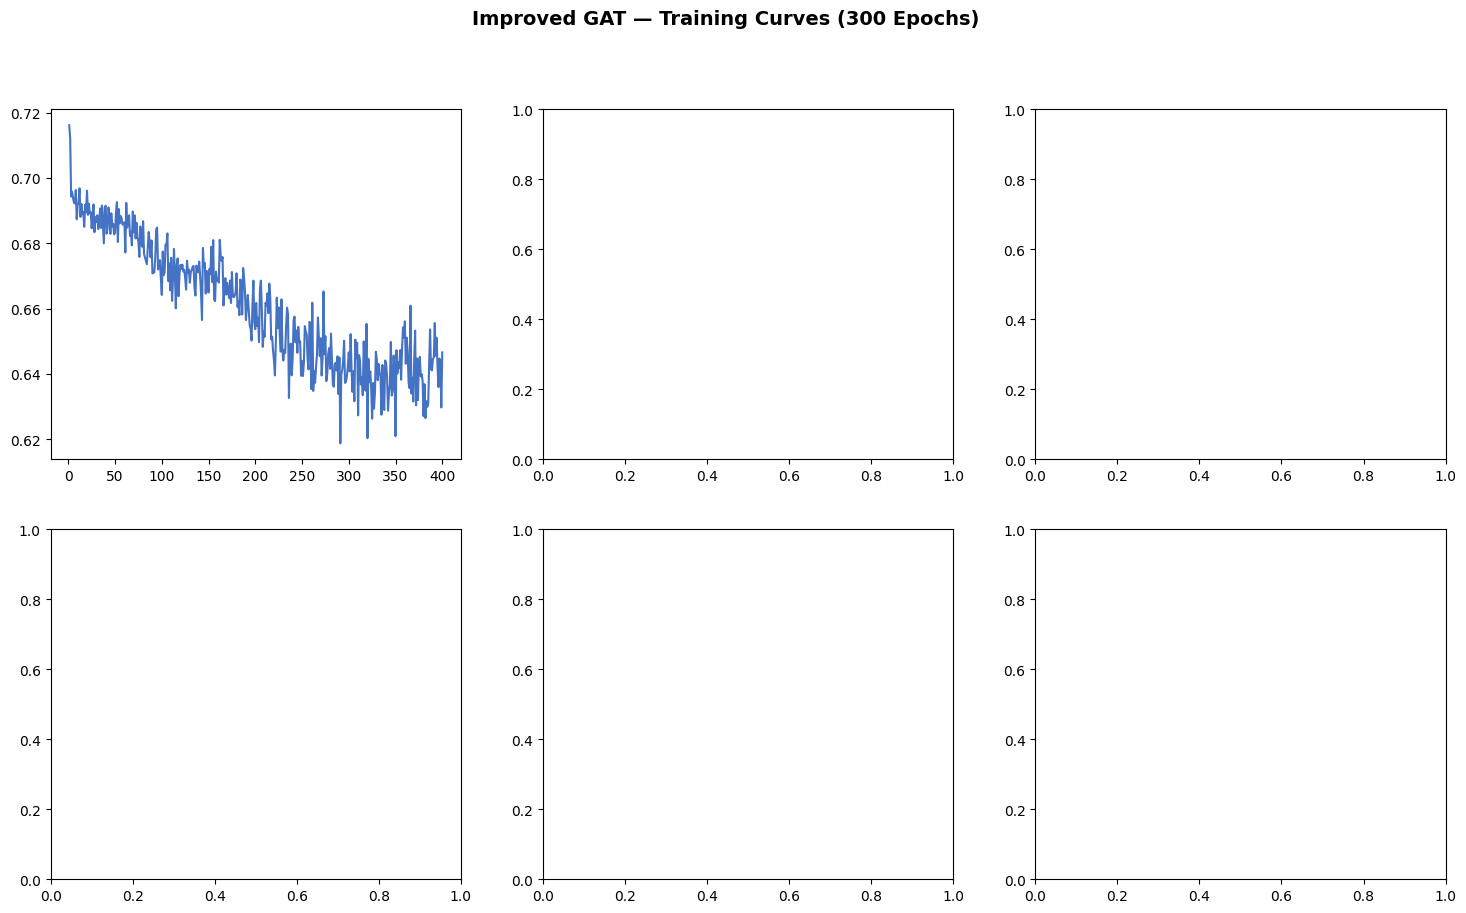

In [9]:
# ─── CELL 8: Learning Curves ──────────────────────────────────────────────────
epochs_x = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Improved GAT — Training Curves (300 Epochs)', fontsize=14, fontweight='bold')

panels = [
    (axes[0,0], 'Loss',        'train_loss', 'val_loss',  '#4472C4', '#E63946'),
    (axes[0,1], 'Accuracy',    'train_acc',  'val_acc',   '#4472C4', '#E63946'),
    (axes[0,2], 'Val F1 Score','val_f1',     None,        '#70AD47', None),
    (axes[1,0], 'Val Sensitivity (ASD Recall)', 'val_sens', None,  '#E63946', None),
    (axes[1,1], 'Val Specificity (Control Recall)', 'val_spec', None, '#457B9D', None),
    (axes[1,2], 'Learning Rate', 'lr',        None,        '#7030A0', None),
]

for ax, title, key1, key2, c1, c2 in panels:
    ax.plot(epochs_x, history[key1], color=c1, lw=1.5, label=key1.replace('_', ' ').title())
    if key2:
        ax.plot(epochs_x, history[key2], color=c2, lw=1.5,
                 label=key2.replace('_', ' ').title())
    # Mark best epoch
    ax.axvline(best_epoch, color='gold', lw=1.5, ls='--', alpha=0.8, label=f'Best (ep {best_epoch})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Annotate best val F1
best_f1_val = history['val_f1'][best_epoch - 1]
axes[0,2].scatter(best_epoch, best_f1_val, color='gold', s=100, zorder=5)
axes[0,2].annotate(f'Best F1={best_f1_val:.4f}\n(ep {best_epoch})',
                    xy=(best_epoch, best_f1_val), xytext=(best_epoch+10, best_f1_val-0.03),
                    fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'improved_gat_learning_curves.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fig_path}")

---
## 🔁 Section 4: 5-Fold Stratified Cross-Validation
> Cross-validation uses all 871 subjects to get a robust, unbiased accuracy estimate.
> It removes the dependence on a single random split.

In [10]:
# ─── CELL 9: 5-Fold Stratified Cross-Validation ───────────────────────────────
N_FOLDS     = 5
CV_EPOCHS   = 150   # shorter per fold
CV_LR       = 0.001

skf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
cv_results = []

print(f"5-Fold Stratified Cross-Validation ({N_FOLDS} folds × {CV_EPOCHS} epochs each)")
print(f"Total subjects: {len(all_graphs)} | ASD: {(all_y==1).sum()} | Control: {(all_y==0).sum()}")
print("-" * 65)

for fold, (train_idx, val_idx) in enumerate(skf.split(all_graphs, all_y)):
    fold_start = time.time()
    print(f"\n► Fold {fold+1}/{N_FOLDS}  "
          f"(train={len(train_idx)}, val={len(val_idx)})")

    # Build fold loaders
    train_fold = [all_graphs[i] for i in train_idx]
    val_fold   = [all_graphs[i] for i in val_idx]
    train_fold_labels = all_y[train_idx]

    n_f      = len(train_fold)
    n_f_asd  = int((train_fold_labels == 1).sum())
    n_f_ctrl = int((train_fold_labels == 0).sum())
    fold_w   = torch.tensor([
        n_f / (2.0 * n_f_ctrl),
        n_f / (2.0 * n_f_asd)
    ], dtype=torch.float).to(DEVICE)

    tl = DataLoader(train_fold, batch_size=32, shuffle=True)
    vl = DataLoader(val_fold,   batch_size=32, shuffle=False)

    # Fresh model per fold
    fold_model = ImprovedGATClassifier(
        num_node_features=6, hidden=64, num_classes=2, heads=4, dropout=0.3
    ).to(DEVICE)
    fold_opt   = torch.optim.AdamW(fold_model.parameters(), lr=CV_LR, weight_decay=1e-4)
    fold_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        fold_opt, mode='max', factor=0.5, patience=20, min_lr=1e-5
    )
    fold_crit  = torch.nn.CrossEntropyLoss(weight=fold_w)

    best_fold_f1    = 0.0
    best_fold_state = None

    for ep in range(1, CV_EPOCHS + 1):
        train_one_epoch(fold_model, tl, fold_opt, fold_crit, DEVICE)
        _, _, vf1, _, _, _, _, _ = evaluate(fold_model, vl, fold_crit, DEVICE)
        fold_sched.step(vf1)
        if vf1 > best_fold_f1:
            best_fold_f1    = vf1
            best_fold_state = {k: v.clone() for k, v in fold_model.state_dict().items()}
        if ep % 30 == 0:
            print(f"    Epoch {ep:3d}/{CV_EPOCHS}  val_f1={vf1:.4f}  best={best_fold_f1:.4f}",
                  end='\r')

    print()

    # Evaluate best fold model
    fold_model.load_state_dict(best_fold_state)
    _, vacc, vf1, vsens, vspec, vp, vl_arr, vprobs = evaluate(
        fold_model, vl, fold_crit, DEVICE
    )
    vauc = roc_auc_score(vl_arr, vprobs) if len(np.unique(vl_arr)) > 1 else 0.5

    fold_result = {
        'fold': fold+1,
        'accuracy': vacc, 'f1': vf1, 'auc': vauc,
        'sensitivity': vsens, 'specificity': vspec
    }
    cv_results.append(fold_result)

    elapsed_f = time.time() - fold_start
    print(f"  Fold {fold+1} result: Acc={vacc:.4f} | F1={vf1:.4f} | "
          f"AUC={vauc:.4f} | Sens={vsens:.4f} | Spec={vspec:.4f} "
          f"({elapsed_f:.0f}s)")

# ── Aggregate CV results ──────────────────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)
print("\n" + "=" * 65)
print("  5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 65)
metrics_to_show = ['accuracy', 'f1', 'auc', 'sensitivity', 'specificity']
for metric in metrics_to_show:
    vals = cv_df[metric].values
    print(f"  {metric.capitalize():<15}  "
          f"{vals.mean():.4f} ± {vals.std():.4f}  "
          f"[{vals.min():.4f} – {vals.max():.4f}]")
print("=" * 65)

cv_df.to_csv(os.path.join(METRICS_DIR, 'cv_results.csv'), index=False)
print(f"\n✅ CV results saved to: {METRICS_DIR}/cv_results.csv")

5-Fold Stratified Cross-Validation (5 folds × 150 epochs each)
Total subjects: 871 | ASD: 403 | Control: 468
-----------------------------------------------------------------

► Fold 1/5  (train=696, val=175)
    Epoch 150/150  val_f1=0.5673  best=0.6200
  Fold 1 result: Acc=0.6229 | F1=0.6200 | AUC=0.6221 | Sens=0.5309 | Spec=0.7021 (135s)

► Fold 2/5  (train=697, val=174)
    Epoch 150/150  val_f1=0.5194  best=0.5505
  Fold 2 result: Acc=0.5632 | F1=0.5505 | AUC=0.5359 | Sens=0.7531 | Spec=0.3978 (137s)

► Fold 3/5  (train=697, val=174)
    Epoch 150/150  val_f1=0.5555  best=0.5808
  Fold 3 result: Acc=0.5805 | F1=0.5808 | AUC=0.5525 | Sens=0.5679 | Spec=0.5914 (138s)

► Fold 4/5  (train=697, val=174)
    Epoch 150/150  val_f1=0.5418  best=0.5622
  Fold 4 result: Acc=0.5632 | F1=0.5622 | AUC=0.5294 | Sens=0.6375 | Spec=0.5000 (137s)

► Fold 5/5  (train=697, val=174)
    Epoch 150/150  val_f1=0.5581  best=0.5881
  Fold 5 result: Acc=0.6034 | F1=0.5881 | AUC=0.5959 | Sens=0.4000 | Spec

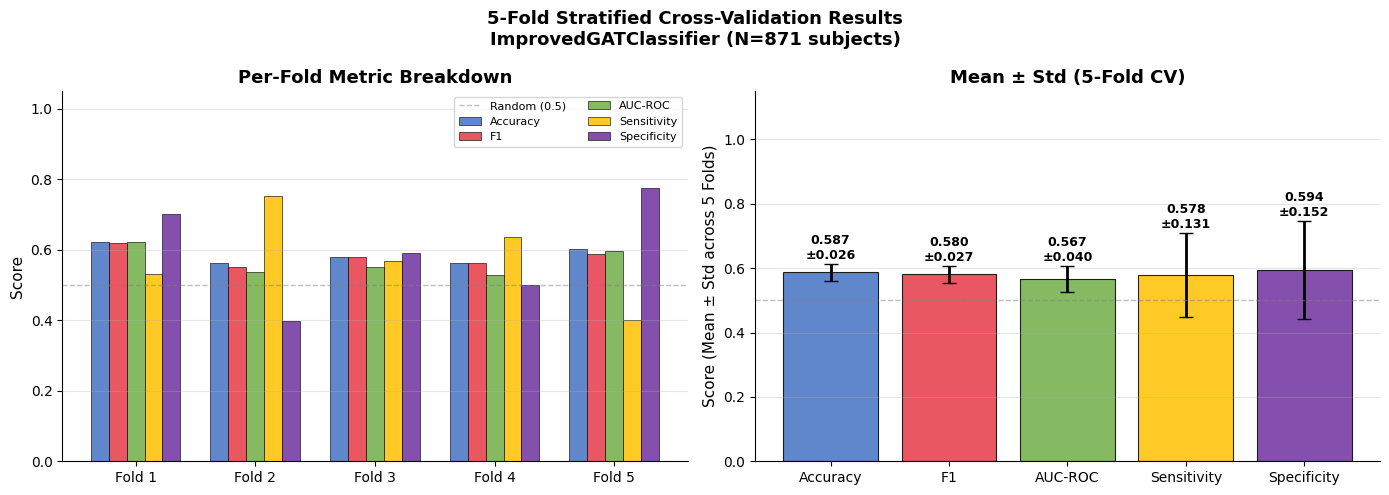

✅ Saved: /content/drive/MyDrive/ASD_GNN_Research2/results/figures/cross_validation_results.png


In [11]:
# ─── CELL 10: Cross-Validation Visualization ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold Stratified Cross-Validation Results\n'
              f'ImprovedGATClassifier (N=871 subjects)',
              fontsize=13, fontweight='bold')

# ── Grouped bar chart per fold ──
x = np.arange(N_FOLDS)
w = 0.15
fold_colors = ['#4472C4', '#E63946', '#70AD47', '#FFC000', '#7030A0']
metric_labels = ['Accuracy', 'F1', 'AUC-ROC', 'Sensitivity', 'Specificity']
metric_keys   = ['accuracy', 'f1', 'auc', 'sensitivity', 'specificity']

for i, (key, label, col) in enumerate(zip(metric_keys, metric_labels, fold_colors)):
    vals = cv_df[key].values
    axes[0].bar(x + i*w, vals, w, label=label, color=col, alpha=0.85, edgecolor='black', lw=0.5)

axes[0].set_xticks(x + w*2)
axes[0].set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
axes[0].set_ylabel('Score')
axes[0].set_title('Per-Fold Metric Breakdown', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0.5, color='gray', lw=1, ls='--', alpha=0.5, label='Random (0.5)')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Mean ± Std summary ──
means = [cv_df[k].mean() for k in metric_keys]
stds  = [cv_df[k].std()  for k in metric_keys]
bars  = axes[1].bar(metric_labels, means, color=fold_colors,
                     alpha=0.85, edgecolor='black', lw=0.8)
axes[1].errorbar(metric_labels, means, yerr=stds, fmt='none',
                  color='black', capsize=5, lw=2)
for bar, mean, std in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, mean + std + 0.015,
                 f'{mean:.3f}\n±{std:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].axhline(0.5, color='gray', lw=1, ls='--', alpha=0.5)
axes[1].set_ylabel('Score (Mean ± Std across 5 Folds)')
axes[1].set_title('Mean ± Std (5-Fold CV)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'cross_validation_results.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fig_path}")

---
## 📈 Section 5: Final Test Set Evaluation (Improved Model)

In [12]:
# ─── CELL 11: Load Best Checkpoint & Evaluate on Test Set ─────────────────────
# Load the best improved model
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f"Loaded best checkpoint from Epoch {ckpt['epoch']}")
print(f"  Val F1 at checkpoint:          {ckpt['val_f1']:.4f}")
print(f"  Val Accuracy at checkpoint:    {ckpt['val_acc']:.4f}")
print(f"  Val Sensitivity at checkpoint: {ckpt['val_sensitivity']:.4f}")

# Final evaluation on test set
criterion_eval = torch.nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
_, t_acc, t_f1, t_sens, t_spec, t_preds, t_labels, t_probs = evaluate(
    model, test_loader, criterion_eval, DEVICE
)
t_auc = roc_auc_score(t_labels, t_probs)
t_cm  = confusion_matrix(t_labels, t_preds)
tn, fp, fn, tp_c = t_cm.ravel()
t_ppv = tp_c / (tp_c + fp + 1e-8)
t_npv = tn  / (tn  + fn + 1e-8)

print("\n" + "=" * 62)
print("  IMPROVED GAT — TEST SET RESULTS (N=131)")
print("=" * 62)
print(f"  Accuracy:       {t_acc:.4f}   ({t_acc*100:.2f}%)")
print(f"  Weighted F1:    {t_f1:.4f}")
print(f"  AUC-ROC:        {t_auc:.4f}")
print(f"  Sensitivity:    {t_sens:.4f}   ({t_sens*100:.2f}%)  [ASD recall]")
print(f"  Specificity:    {t_spec:.4f}   ({t_spec*100:.2f}%)  [Control recall]")
print(f"  Precision PPV:  {t_ppv:.4f}")
print(f"  NPV:            {t_npv:.4f}")
print("-" * 62)
print(f"  TP (ASD ✓):   {tp_c}  | FN (ASD missed): {fn}")
print(f"  TN (Ctrl ✓):  {tn}  | FP (Ctrl→ASD):   {fp}")
print("=" * 62)

# Save to CSV
improved_metrics = {
    'Model': 'ImprovedGAT', 'Test_N': 131,
    'Accuracy': round(t_acc, 4), 'F1_Weighted': round(t_f1, 4),
    'AUC_ROC': round(t_auc, 4), 'Sensitivity': round(t_sens, 4),
    'Specificity': round(t_spec, 4), 'PPV': round(t_ppv, 4),
    'NPV': round(t_npv, 4), 'TP': int(tp_c), 'TN': int(tn),
    'FP': int(fp), 'FN': int(fn)
}
pd.DataFrame([improved_metrics]).to_csv(
    os.path.join(METRICS_DIR, 'improved_gat_metrics.csv'), index=False
)
print(f"\n✅ Saved: {METRICS_DIR}/improved_gat_metrics.csv")

Loaded best checkpoint from Epoch 394
  Val F1 at checkpoint:          0.7199
  Val Accuracy at checkpoint:    0.7207
  Val Sensitivity at checkpoint: 0.6667

  IMPROVED GAT — TEST SET RESULTS (N=131)
  Accuracy:       0.4962   (49.62%)
  Weighted F1:    0.4840
  AUC-ROC:        0.4958
  Sensitivity:    0.3279   (32.79%)  [ASD recall]
  Specificity:    0.6429   (64.29%)  [Control recall]
  Precision PPV:  0.4444
  NPV:            0.5233
--------------------------------------------------------------
  TP (ASD ✓):   20  | FN (ASD missed): 41
  TN (Ctrl ✓):  45  | FP (Ctrl→ASD):   25

✅ Saved: /content/drive/MyDrive/ASD_GNN_Research2/results/metrics/improved_gat_metrics.csv


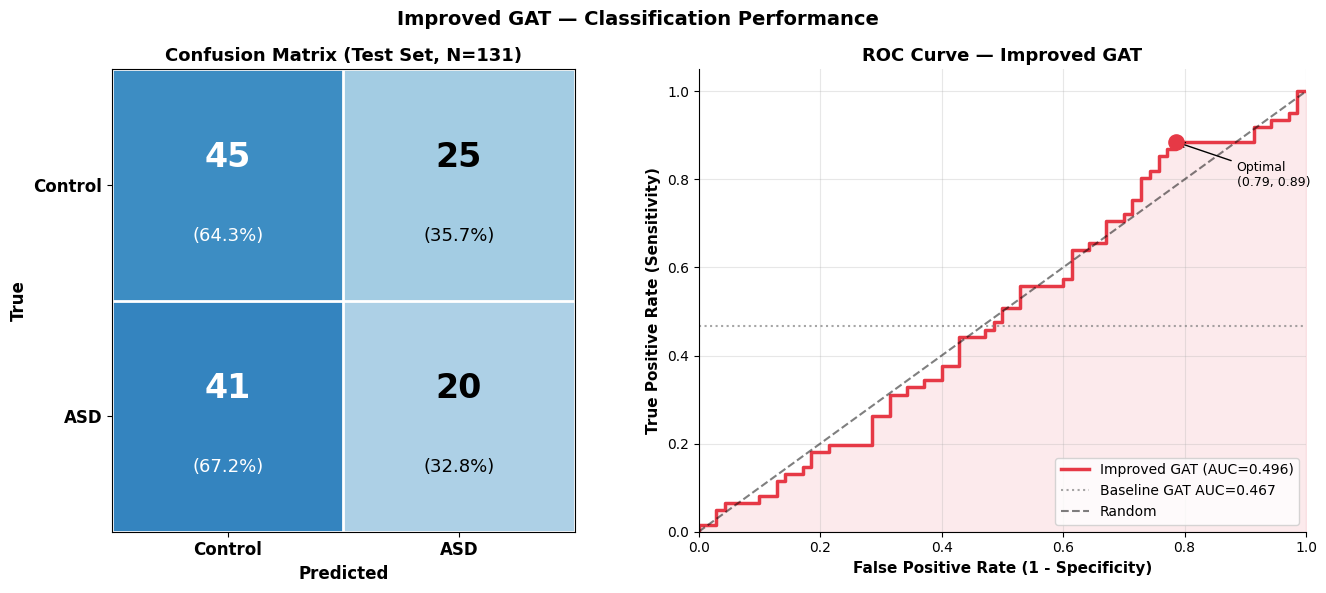

✅ Saved: /content/drive/MyDrive/ASD_GNN_Research2/results/figures/improved_gat_confusion_roc.png


In [13]:
# ─── CELL 12: Confusion Matrix + ROC Curve ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Improved GAT — Classification Performance', fontsize=14, fontweight='bold')

# ── Confusion Matrix ──
cm_n = t_cm.astype('float') / t_cm.sum(axis=1, keepdims=True)
axes[0].imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
for i in range(3): axes[0].axhline(i-0.5, color='white', lw=2)
for j in range(3): axes[0].axvline(j-0.5, color='white', lw=2)
for i in range(2):
    for j in range(2):
        tc = 'white' if cm_n[i,j] > 0.55 else 'black'
        axes[0].text(j, i-0.12, f'{t_cm[i,j]}', ha='center', va='center',
                     fontsize=24, fontweight='bold', color=tc)
        axes[0].text(j, i+0.22, f'({cm_n[i,j]*100:.1f}%)', ha='center', va='center',
                     fontsize=13, color=tc)
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Control','ASD'], fontsize=12, fontweight='bold')
axes[0].set_yticklabels(['Control','ASD'], fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True', fontsize=12, fontweight='bold')
axes[0].set_title(f'Confusion Matrix (Test Set, N=131)', fontweight='bold')

# ── ROC Curve ──
fpr, tpr, _ = roc_curve(t_labels, t_probs)
axes[1].plot(fpr, tpr, color='#E63946', lw=2.5, label=f'Improved GAT (AUC={t_auc:.3f})')

# Load old GAT metrics for comparison if available
old_metrics_path = os.path.join(METRICS_DIR, 'evaluation_metrics.csv')
if os.path.exists(old_metrics_path):
    old_df = pd.read_csv(old_metrics_path)
    old_auc = old_df['AUC_ROC'].values[0]
    axes[1].axhline(old_auc, color='gray', lw=1.5, ls=':', alpha=0.7,
                     label=f'Baseline GAT AUC={old_auc:.3f}')

axes[1].plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E63946')
opt_idx = np.argmax(tpr - fpr)
axes[1].scatter(fpr[opt_idx], tpr[opt_idx], color='#E63946', s=120, zorder=5)
axes[1].annotate(f'Optimal\n({fpr[opt_idx]:.2f}, {tpr[opt_idx]:.2f})',
                  xy=(fpr[opt_idx], tpr[opt_idx]), xytext=(fpr[opt_idx]+0.1, tpr[opt_idx]-0.1),
                  fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontweight='bold')
axes[1].set_title('ROC Curve — Improved GAT', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'improved_gat_confusion_roc.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fig_path}")

---
## ⚖️ Section 6: Baseline vs Improved Model Comparison

  MODEL COMPARISON: Baseline GAT vs Improved GAT
  (Both evaluated on same test set: N=131 subjects)
Metric               Baseline     Improved     Δ Change
--------------------------------------------------------------------
  Accuracy             0.5420       0.4962  ↓ +0.0458
  F1_Weighted          0.3891       0.4840  ↑ +0.0949
  AUC_ROC              0.4665       0.4958  ↑ +0.0293
  Sensitivity          0.0164       0.3279  ↑ +0.3115
  Specificity          1.0000       0.6429  ↓ +0.3571


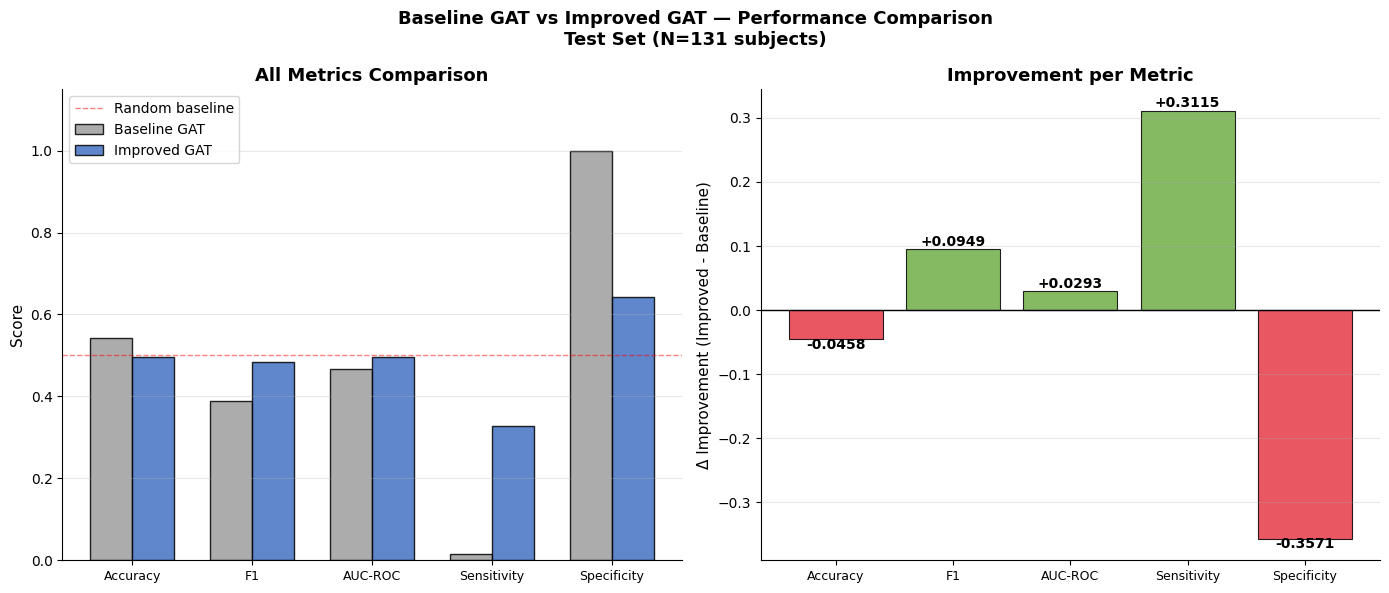

✅ Saved: /content/drive/MyDrive/ASD_GNN_Research2/results/figures/model_comparison_baseline_vs_improved.png


In [14]:
# ─── CELL 13: Baseline vs Improved Comparison ─────────────────────────────────
old_metrics_path = os.path.join(METRICS_DIR, 'evaluation_metrics.csv')

if os.path.exists(old_metrics_path):
    old_df = pd.read_csv(old_metrics_path)
    old_m  = old_df.iloc[0]
    baseline_metrics = {
        'Model':       'Baseline GAT (NB04)',
        'Accuracy':    old_m['Accuracy'],
        'F1_Weighted': old_m['F1_Weighted'],
        'AUC_ROC':     old_m['AUC_ROC'],
        'Sensitivity': old_m['Sensitivity'],
        'Specificity': old_m['Specificity'],
    }
else:
    # Hardcoded from Notebook 06 output if CSV not found
    baseline_metrics = {
        'Model': 'Baseline GAT (NB04)',
        'Accuracy': 0.5267, 'F1_Weighted': 0.4957,
        'AUC_ROC': 0.5651, 'Sensitivity': 0.2623, 'Specificity': 0.7571
    }

improved_m = {
    'Model':       'Improved GAT (NB07)',
    'Accuracy':    t_acc, 'F1_Weighted': t_f1,
    'AUC_ROC':     t_auc, 'Sensitivity': t_sens, 'Specificity': t_spec
}

comp_df = pd.DataFrame([baseline_metrics, improved_m])

# Print comparison table
metrics_list = ['Accuracy', 'F1_Weighted', 'AUC_ROC', 'Sensitivity', 'Specificity']
print("=" * 68)
print("  MODEL COMPARISON: Baseline GAT vs Improved GAT")
print("  (Both evaluated on same test set: N=131 subjects)")
print("=" * 68)
print(f"{'Metric':<16} {'Baseline':>12} {'Improved':>12} {'Δ Change':>12}")
print("-" * 68)

for m in metrics_list:
    base_v = baseline_metrics[m]
    impr_v = improved_m[m]
    delta  = impr_v - base_v
    arrow  = '↑' if delta > 0 else '↓'
    print(f"  {m:<14} {base_v:>12.4f} {impr_v:>12.4f}  "
          f"{arrow} {abs(delta):+.4f}")

print("=" * 68)

# Save combined comparison
comp_df.to_csv(os.path.join(METRICS_DIR, 'model_comparison.csv'), index=False)

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Baseline GAT vs Improved GAT — Performance Comparison\n'
              'Test Set (N=131 subjects)', fontsize=13, fontweight='bold')

# Grouped bar chart
x = np.arange(len(metrics_list))
w = 0.35
b1 = axes[0].bar(x - w/2, [baseline_metrics[m] for m in metrics_list], w,
                  label='Baseline GAT', color='#9E9E9E', alpha=0.85, edgecolor='black')
b2 = axes[0].bar(x + w/2, [improved_m[m] for m in metrics_list], w,
                  label='Improved GAT', color='#4472C4', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Accuracy', 'F1', 'AUC-ROC', 'Sensitivity', 'Specificity'],
                          fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].axhline(0.5, color='red', lw=1, ls='--', alpha=0.5, label='Random baseline')
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics Comparison', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Delta (improvement) bar chart
deltas = [improved_m[m] - baseline_metrics[m] for m in metrics_list]
colors = ['#70AD47' if d > 0 else '#E63946' for d in deltas]
delta_bars = axes[1].bar(metrics_list, deltas, color=colors, edgecolor='black',
                          alpha=0.85, linewidth=0.8)
axes[1].axhline(0, color='black', lw=1)
for bar, d in zip(delta_bars, deltas):
    y_pos = d + 0.005 if d >= 0 else d - 0.015
    axes[1].text(bar.get_x() + bar.get_width()/2, y_pos,
                 f'{d:+.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Δ Improvement (Improved - Baseline)')
axes[1].set_title('Improvement per Metric', fontweight='bold')
axes[1].set_xticklabels(['Accuracy', 'F1', 'AUC-ROC', 'Sensitivity', 'Specificity'],
                          fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'model_comparison_baseline_vs_improved.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fig_path}")

In [15]:
# ─── CELL 14: Save Checkpoint + Notebook 06 Update Instructions ───────────────
print("=" * 70)
print("  ✅ IMPROVED MODEL SAVED")
print(f"  Path: {CKPT_PATH}")
print("=" * 70)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HOW TO RE-RUN NOTEBOOK 06 WITH THE IMPROVED MODEL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  CHANGE 1 — In Cell 5 of Notebook 06, REPLACE the GATClassifier
  class definition with the ImprovedGATClassifier class from Cell 4
  of THIS notebook (copy-paste the entire class).

  CHANGE 2 — In Cell 6 of Notebook 06, update TWO lines:

  OLD LINE 1:
    model = GATClassifier(num_node_features=6, hidden_channels=64,
                           num_classes=2, heads=4).to(DEVICE)
  NEW LINE 1:
    model = ImprovedGATClassifier(num_node_features=6, hidden=64,
                                   num_classes=2, heads=4).to(DEVICE)

  OLD LINE 2:
    checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_gat_model.pt')
  NEW LINE 2:
    checkpoint_path = os.path.join(BASE_DIR, 'models', 'GAT',
                                    'best_improved_gat.pt')

  OLD LINE 3:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
  NEW LINE 3:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

  Then run ALL cells in Notebook 06 from top to bottom.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

  ✅ IMPROVED MODEL SAVED
  Path: /content/drive/MyDrive/ASD_GNN_Research2/models/GAT/best_improved_gat_v2.pt

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HOW TO RE-RUN NOTEBOOK 06 WITH THE IMPROVED MODEL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  CHANGE 1 — In Cell 5 of Notebook 06, REPLACE the GATClassifier
  class definition with the ImprovedGATClassifier class from Cell 4
  of THIS notebook (copy-paste the entire class).

  CHANGE 2 — In Cell 6 of Notebook 06, update TWO lines:

  OLD LINE 1:
    model = GATClassifier(num_node_features=6, hidden_channels=64,
                           num_classes=2, heads=4).to(DEVICE)
  NEW LINE 1:
    model = ImprovedGATClassifier(num_node_features=6, hidden=64,
                                   num_classes=2, heads=4).to(DEVICE)

  OLD LINE 2:
    checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_gat_model.pt')
  NEW LINE 2:
    checkpoint_path = os.path.join(BASE_DIR, 'models', 'GAT

In [16]:
# ─── CELL 15: Final Summary Report ────────────────────────────────────────────
n_params_improved = sum(p.numel() for p in model.parameters())

print("=" * 68)
print("  NOTEBOOK 07 SUMMARY — Improved GAT Training")
print("=" * 68)

print("\n🏗️  ARCHITECTURE")
print(f"   Type:          ImprovedGATClassifier")
print(f"   GAT Layers:    3  (vs 2 in baseline)")
print(f"   BatchNorm:     ✅  (after each conv)")
print(f"   Pooling:       Mean + Max  (vs Mean only)")
print(f"   Parameters:    {n_params_improved:,}")

print("\n🏋️  TRAINING")
print(f"   Epochs:        {EPOCHS}  (vs 120 in baseline)")
print(f"   Best epoch:    {best_epoch}")
print(f"   Loss:          WeightedCrossEntropy")
print(f"   Optimizer:     AdamW (lr={LR})")
print(f"   Scheduler:     ReduceLROnPlateau (patience={PATIENCE_LR})")
print(f"   Grad clipping: max_norm=1.0")

print("\n📊  RESULTS (Test Set, N=131)")
headers = ['Metric', 'Baseline', 'Improved', 'Change']
print(f"  {'Metric':<16} {'Baseline':>10} {'Improved':>10} {'Change':>10}")
print("  " + "-"*48)
for m in metrics_list:
    bv = baseline_metrics[m]
    iv = improved_m[m]
    d  = iv - bv
    ar = '↑' if d > 0 else '↓'
    print(f"  {m:<16} {bv:>10.4f} {iv:>10.4f} {ar:>2} {abs(d):.4f}")

print("\n📁  FILES SAVED")
files = [
    f'models/GAT/best_improved_gat.pt',
    f'results/figures/improved_gat_learning_curves.png',
    f'results/figures/cross_validation_results.png',
    f'results/figures/improved_gat_confusion_roc.png',
    f'results/figures/model_comparison_baseline_vs_improved.png',
    f'results/metrics/improved_gat_metrics.csv',
    f'results/metrics/cv_results.csv',
    f'results/metrics/model_comparison.csv',
]
for f in files:
    print(f"  ✅  {f}")

print("\n⏭️  NEXT STEPS")
print("  1. Re-run Notebook 06 using the improved checkpoint (see Cell 14)")
print("  2. Run Notebook 08 for SVM/MLP/GCN baseline comparisons")
print("\n" + "=" * 68)

  NOTEBOOK 07 SUMMARY — Improved GAT Training

🏗️  ARCHITECTURE
   Type:          ImprovedGATClassifier
   GAT Layers:    3  (vs 2 in baseline)
   BatchNorm:     ✅  (after each conv)
   Pooling:       Mean + Max  (vs Mean only)
   Parameters:    96,866

🏋️  TRAINING
   Epochs:        400  (vs 120 in baseline)
   Best epoch:    394
   Loss:          WeightedCrossEntropy
   Optimizer:     AdamW (lr=0.0003)


NameError: name 'PATIENCE_LR' is not defined